# MULTIPLE LINEAR REGRESSION

#### 1.Perform exploratory data analysis (EDA) to gain insights into the dataset. Provide visualizations and summary statistics of the variables. Pre-process the data to apply the MLR.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Lasso, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [5]:
# load the data
data = pd.read_csv('ToyotaCorolla - MLR.csv')
data.head()

,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
0,13500,23,46986,Diesel,90,0,2000,3,4,5,1165
1,13750,23,72937,Diesel,90,0,2000,3,4,5,1165
2,13950,24,41711,Diesel,90,0,2000,3,4,5,1165
3,14950,26,48000,Diesel,90,0,2000,3,4,5,1165
4,13750,30,38500,Diesel,90,0,2000,3,4,5,1170


In [6]:
# dataset information
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Price      1436 non-null   int64 
 1   Age_08_04  1436 non-null   int64 
 2   KM         1436 non-null   int64 
 3   Fuel_Type  1436 non-null   object
 4   HP         1436 non-null   int64 
 5   Automatic  1436 non-null   int64 
 6   cc         1436 non-null   int64 
 7   Doors      1436 non-null   int64 
 8   Cylinders  1436 non-null   int64 
 9   Gears      1436 non-null   int64 
 10  Weight     1436 non-null   int64 
dtypes: int64(10), object(1)
memory usage: 123.5+ KB


In [8]:
#summary statistics of data
data.describe()

,Price,Age_08_04,KM,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
count,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.00000,1436.000000,1436.0,1436.000000,1436.00000
mean,10730.824513,55.947075,68533.259749,101.502089,0.055710,1576.85585,4.033426,4.0,5.026462,1072.45961
std,3626.964585,18.599988,37506.448872,14.981080,0.229441,424.38677,0.952677,0.0,0.188510,52.64112
min,4350.000000,1.000000,1.000000,69.000000,0.000000,1300.00000,2.000000,4.0,3.000000,1000.00000
25%,8450.000000,44.000000,43000.000000,90.000000,0.000000,1400.00000,3.000000,4.0,5.000000,1040.00000
50%,9900.000000,61.000000,63389.500000,110.000000,0.000000,1600.00000,4.000000,4.0,5.000000,1070.00000
75%,11950.000000,70.000000,87020.750000,110.000000,0.000000,1600.00000,5.000000,4.0,5.000000,1085.00000
max,32500.000000,80.000000,243000.000000,192.000000,1.000000,16000.00000,5.000000,4.0,6.000000,1615.00000


In [9]:
#check the missing values
data.isnull().sum()

Price        0
Age_08_04    0
KM           0
Fuel_Type    0
HP           0
Automatic    0
cc           0
Doors        0
Cylinders    0
Gears        0
Weight       0
dtype: int64

In [11]:
#checking the duplicate valued
data.duplicated().sum()

np.int64(1)

In [12]:
# remove the duplicated
data = data.drop_duplicates()

In [14]:
data.duplicated().sum()
#duplicates dropped

np.int64(0)

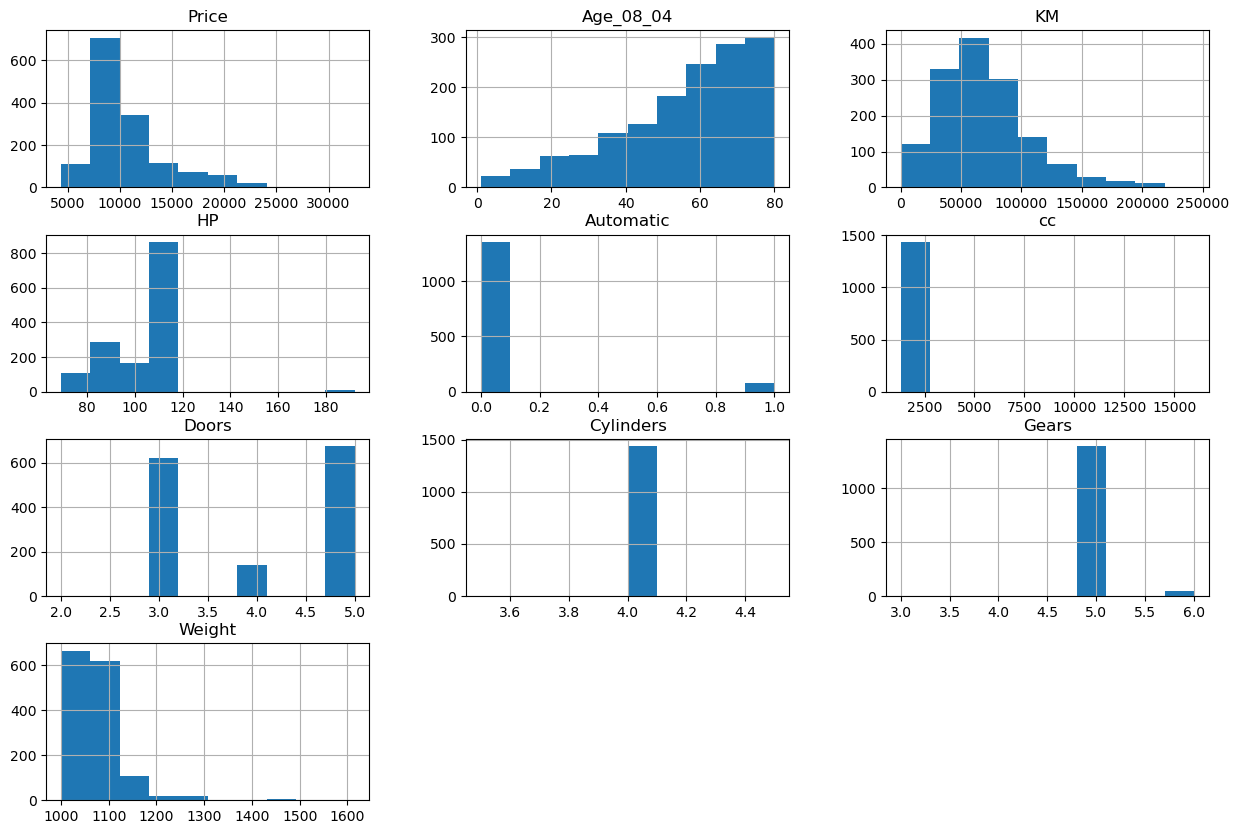

In [15]:
# visualizing the data using histogram
data.hist(figsize= (15, 10))
plt.show()

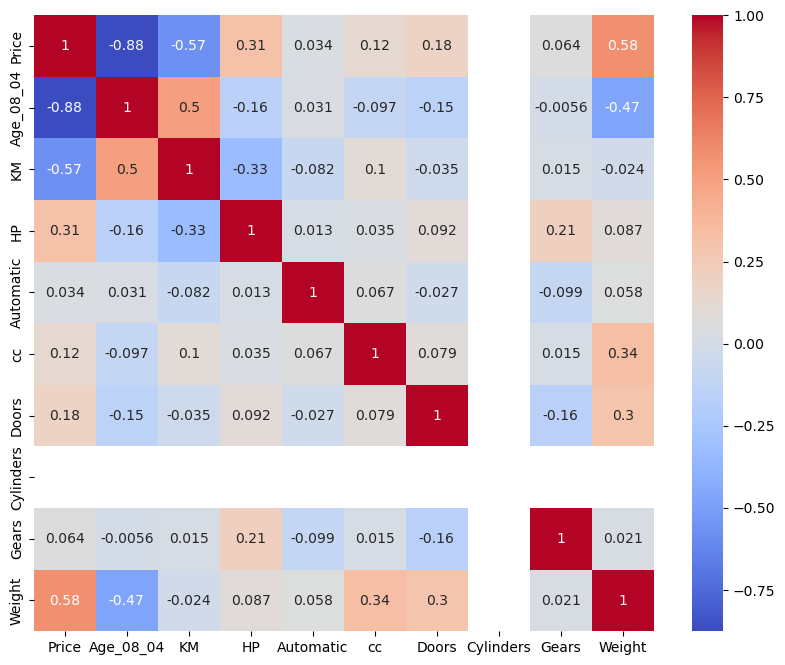

In [16]:
#correlation heatmap
plt.figure(figsize = (10,8))
sns.heatmap(data.corr(numeric_only = True), annot = True, cmap = 'coolwarm')
plt.show()

In [18]:
#Encoding FuelType

if 'Fuel_Type' in df.columns:
    df = pd.get_dummies(df, columns=['Fuel_Type'], drop_first=True)
else:
    print("Column 'Fuel_Type' not found in DataFrame. It might have already been encoded.")

Column 'Fuel_Type' not found in DataFrame. It might have already been encoded.


#### 2.Split the dataset into training and testing sets (e.g., 80% training, 20% testing).

In [19]:
# defining features and target
X = df.drop('Price', axis = 1)
y = df['Price']

In [51]:
#splitting dataset
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size = 0.20, random_state = 42)
X_train, X_test, y_train, y_test

(      Age_08_04      KM   HP  Automatic    cc  Doors  Cylinders  Gears  \
 899          62   59295   86          0  1300      5          4      5   
 881          68   61568  110          0  1600      4          4      5   
 310          40   38653  110          0  1600      5          4      5   
 1145         75  101855  110          0  1600      5          4      5   
 31           22   35199   97          0  1400      3          4      5   
 ...         ...     ...  ...        ...   ...    ...        ...    ...   
 1095         76  125778  110          0  1600      3          4      5   
 1130         73  107108  110          0  1600      3          4      5   
 1294         80   71740  110          0  1600      5          4      5   
 860          63   64690   86          0  1300      3          4      5   
 1126         80  110000  110          0  1600      4          4      5   
 
       Weight  Fuel_Type_Diesel  Fuel_Type_Petrol  
 899     1035             False              T

#### 3.Build a multiple linear regression model using the training dataset. Interpret the coefficients of the model. Build a minimum of 3 different models.

In [52]:
# model 1
X1 = df[['Age_08_04','KM','HP','Weight']]

X1_train, X1_test, y1_train, y1_test = train_test_split(
    X1, y, test_size=0.20, random_state=42
)

model1 = LinearRegression()
model1.fit(X1_train, y1_train)

print(model1.coef_)

[-1.20025405e+02 -2.02325920e-02  2.90521704e+01  1.97690662e+01]


In [53]:
# model2
X2 = df[['Age_08_04','KM','HP', 'cc', 'Weight']]

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y, test_size=0.20, random_state=42
)

model2 = LinearRegression()
model2.fit(X2_train, y2_train)

print(model2.coef_)

[-1.19972882e+02 -2.01056597e-02  2.91949637e+01 -1.00760393e-01
  2.00843833e+01]


In [54]:
#model3
X3 = df[['Age_08_04','KM','HP','cc','Weight']]

X3_train, X3_test, y3_train, y3_test = train_test_split(
    X3, y, test_size=0.20, random_state=42
)

model3 = LinearRegression()
model3.fit(X3_train, y3_train)

print(model3.coef_)

[-1.19972882e+02 -2.01056597e-02  2.91949637e+01 -1.00760393e-01
  2.00843833e+01]


In [55]:
coef_table = pd.DataFrame({
    'Feature': X3.columns,
    'Coefficient': model3.coef_
})

print(coef_table)

     Feature  Coefficient
0  Age_08_04  -119.972882
1         KM    -0.020106
2         HP    29.194964
3         cc    -0.100760
4     Weight    20.084383


#### 4.Evaluate the performance of the model using appropriate evaluation metrics on the testing dataset.

In [56]:
# predict the y values
yhat1 = model1.predict(X1_test)

# evaluating model 1
mae = mean_absolute_error(y1_test, yhat1)
mse = mean_squared_error(y1_test, yhat1)
rmse = np.sqrt(mse)
r2 = r2_score(y1_test,yhat1)

In [57]:
print("Mean Absolute Error(MAE) : ",np.round(mae,2),'\nMean Squared Error (MSE) : ',{np.round(mse,2)},'\nRoot MEAn Squared Error (RMSE) : ',{np.round(rmse,2)},'\nR_Squared (R2) : ',{np.round(r2,2)})

Mean Absolute Error(MAE) :  1001.2 
Mean Squared Error (MSE) :  {np.float64(1993321.01)} 
Root MEAn Squared Error (RMSE) :  {np.float64(1411.85)} 
R_Squared (R2) :  {np.float64(0.85)}


In [58]:
# predict the y values
yhat2 = model2.predict(X2_test)

# evaluating model 2
mae = mean_absolute_error(y2_test, yhat2)
mse = mean_squared_error(y2_test, yhat2)
rmse = np.sqrt(mse)
r2 = r2_score(y2_test,yhat2)

In [59]:
print("Mean Absolute Error(MAE) : ",np.round(mae,2),'\nMean Squared Error (MSE) : ',{np.round(mse,2)},'\nRoot MEAn Squared Error (RMSE) : ',{np.round(rmse,2)},'\nR_Squared (R2) : ',{np.round(r2,2)})

Mean Absolute Error(MAE) :  998.54 
Mean Squared Error (MSE) :  {np.float64(1995964.84)} 
Root MEAn Squared Error (RMSE) :  {np.float64(1412.79)} 
R_Squared (R2) :  {np.float64(0.85)}


In [60]:
# predict the y values
yhat3 = model3.predict(X3_test)

# evaluating model 3
mae = mean_absolute_error(y3_test, yhat3)
mse = mean_squared_error(y3_test, yhat3)
rmse = np.sqrt(mse)
r2 = r2_score(y3_test,yhat3)

In [61]:
print("Mean Absolute Error(MAE) : ",np.round(mae,2),'\nMean Squared Error (MSE) : ',{np.round(mse,2)},'\nRoot MEAn Squared Error (RMSE) : ',{np.round(rmse,2)},'\nR_Squared (R2) : ',{np.round(r2,2)})

Mean Absolute Error(MAE) :  998.54 
Mean Squared Error (MSE) :  {np.float64(1995964.84)} 
Root MEAn Squared Error (RMSE) :  {np.float64(1412.79)} 
R_Squared (R2) :  {np.float64(0.85)}


#### 5.Apply Lasso and Ridge methods on the model.

In [62]:
# Ridge method
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

ridge_pred = ridge.predict(X_test)

print("R2 Score:", r2_score(y_test, ridge_pred))

R2 Score: 0.835135937771234


In [64]:
#lasso method

lasso = Lasso(alpha=1.0)
lasso.fit(X_train, y_train)

lasso_pred = lasso.predict(X_test)

print("R2 Score:", r2_score(y_test, lasso_pred))

R2 Score: 0.8354626403967389


##### Conclusion : Multiple Linear Regression, Ridge Regression, and Lasso Regression were used to predict Toyota Corolla prices. The models were evaluated using MAE, MSE, RMSE, and R² score, and the best-performing model can be selected based on these metrics.|

# Interview Questions

#### 1. What is Normalization and Standardization? How is it Helpful?

##### *Normalization is a method used to scale data values into a fixed range, usually between 0 and 1.

##### *Standardization is a method used to transform data so that all features have a similar scale around the average value.

##### Normalization and standardization help machine learning models perform better by ensuring that all features are treated fairly. They prevent features with larger values from having a greater influence on the model and can improve both accuracy and training speed.

#### 2. What Techniques Can Be Used to Address Multicollinearity in Multiple Linear Regression?

##### Multicollinearity occurs when two or more independent variables are highly related to each other. This can make the model unstable and difficult to interpret.

##### Some common ways to handle it are:

##### Removing highly correlated variables. Selecting only the most important features. Using VIF (Variance Inflation Factor) to identify problematic variables. Applying Ridge Regression or Lasso Regression. Using PCA to reduce the number of correlated features.